Training data shape: (60000, 28, 28)
Test data shape: (10000, 28, 28)
Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.8680 - loss: 0.4632 - val_accuracy: 0.9657 - val_loss: 0.1157
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.9707 - loss: 0.0974 - val_accuracy: 0.9674 - val_loss: 0.1068
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.9831 - loss: 0.0553 - val_accuracy: 0.9687 - val_loss: 0.1027
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9871 - loss: 0.0398 - val_accuracy: 0.9744 - val_loss: 0.0890
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.9904 - loss: 0.0285 - val_accuracy: 0.9762 - val_loss: 0.0821
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.9947 - loss: 0.0181 - val_accuracy: 0.9778 - val_loss: 0.0830
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.9952 - loss: 0.0149 - val_accuracy: 0.9725 - val_loss: 0.0959
Epoch 8/10
375/375 ━━━━━━━

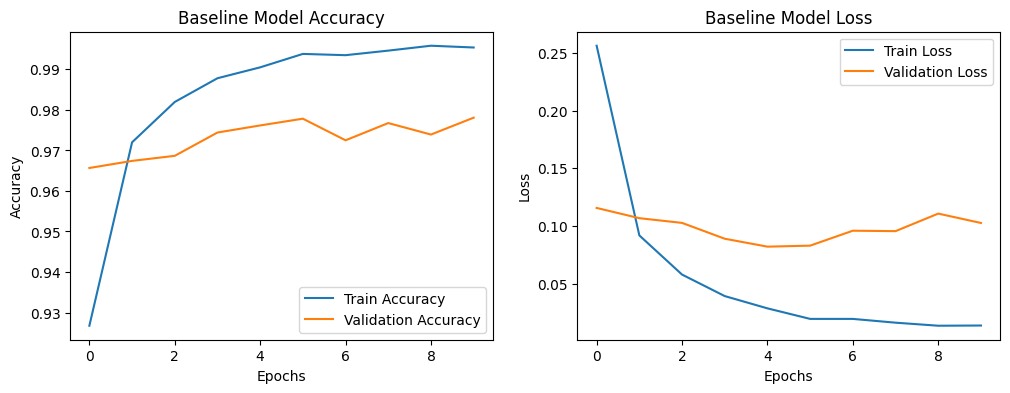

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf   #deep learning framework
from tensorflow.keras.datasets import mnist # MNIST dataset loader
from tensorflow.keras.models import Sequential # linear stack of layers
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Flatten
#  Dense:- fully connected layer
# Dropout:- prevents overfitting
# BatchNormalization:- stabilizes training
# Flatten:-converts 2D image into 1D vector

from tensorflow.keras.regularizers import l2

# Load dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize pixel values (0–255 → 0–1)
x_train = x_train / 255.0  # Images are stored using 8-bit grayscale 0 → black 255 → white
x_test = x_test / 255.0

print("Training data shape:", x_train.shape)
print("Test data shape:", x_test.shape)

def plot_history(history, title):
    plt.figure(figsize=(12, 4))

    # Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(title + ' Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    # Loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(title + ' Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()

#Model Definition
baseline_model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(512, activation='relu'),
    Dense(256, activation='relu'),
    Dense(10, activation='softmax')
])


baseline_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_baseline = baseline_model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

plot_history(history_baseline, "Baseline Model")


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.7710 - loss: 0.7175 - val_accuracy: 0.9547 - val_loss: 0.1463
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.9367 - loss: 0.2113 - val_accuracy: 0.9667 - val_loss: 0.1113
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.9531 - loss: 0.1520 - val_accuracy: 0.9705 - val_loss: 0.0956
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.9620 - loss: 0.1244 - val_accuracy: 0.9743 - val_loss: 0.0860
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.9668 - loss: 0.1101 - val_accuracy: 0.9750 - val_loss: 0.0821
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.9722 - loss: 0.0928 - val_accuracy: 0.9760 - val_loss: 0.0799
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.9720 - loss: 0.0878 - val_accuracy: 0.9785 - val_loss: 0.0760
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.9750 - loss: 0.0793 - val_accu

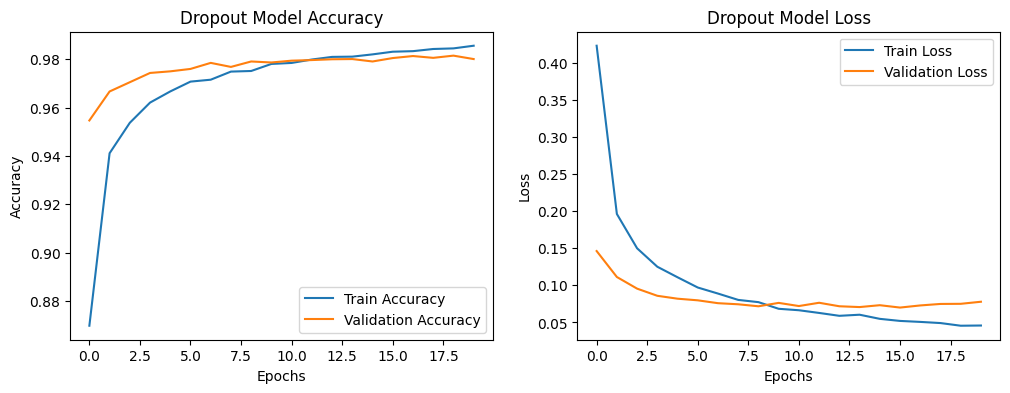

In [ ]:
# Model with Dropout Regularization
dropout_model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])
dropout_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
history_dropout = dropout_model.fit(
    x_train, y_train,
    epochs=20,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)
plot_history(history_dropout, "Dropout Model")


Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.8608 - loss: 1.0590 - val_accuracy: 0.9573 - val_loss: 0.4077
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.9595 - loss: 0.3706 - val_accuracy: 0.9649 - val_loss: 0.2883
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.9682 - loss: 0.2603 - val_accuracy: 0.9634 - val_loss: 0.2462
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.9734 - loss: 0.2148 - val_accuracy: 0.9676 - val_loss: 0.2200
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - accuracy: 0.9746 - loss: 0.1951 - val_accuracy: 0.9707 - val_loss: 0.2060
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.9779 - loss: 0.1818 - val_accuracy: 0.9725 - val_loss: 0.1944
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.9782 - loss: 0.1730 - val_accuracy: 0.9714 - val_loss: 0.1867
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - accuracy: 0.9792 - loss: 0.1621 - val_a

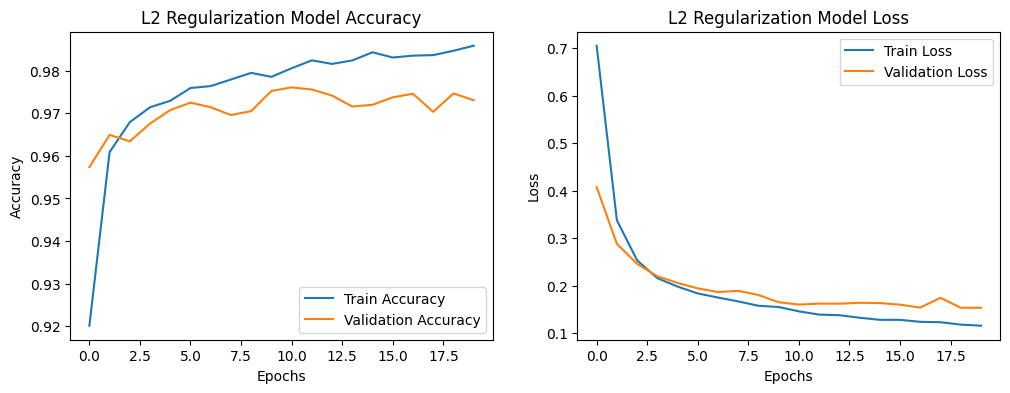

In [ ]:
# Model with L2 Regularization
l2_model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(512, activation='relu', kernel_regularizer=l2(0.001)),
    Dense(256, activation='relu', kernel_regularizer=l2(0.001)),
    Dense(10, activation='softmax')
])
l2_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
history_l2 = l2_model.fit(
    x_train, y_train,
    epochs=20,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)
plot_history(history_l2, "L2 Regularization Model")


Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.8954 - loss: 0.3460 - val_accuracy: 0.9673 - val_loss: 0.1179
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - accuracy: 0.9786 - loss: 0.0709 - val_accuracy: 0.9692 - val_loss: 0.0982
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.9857 - loss: 0.0441 - val_accuracy: 0.9730 - val_loss: 0.0912
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.9889 - loss: 0.0323 - val_accuracy: 0.9672 - val_loss: 0.1100
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.9919 - loss: 0.0250 - val_accuracy: 0.9722 - val_loss: 0.1000
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.9948 - loss: 0.0175 - val_accuracy: 0.9751 - val_loss: 0.0889
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.9946 - loss: 0.0186 - val_accuracy: 0.9734 - val_loss: 0.1056
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.9941 - loss: 0.0178 - val_ac

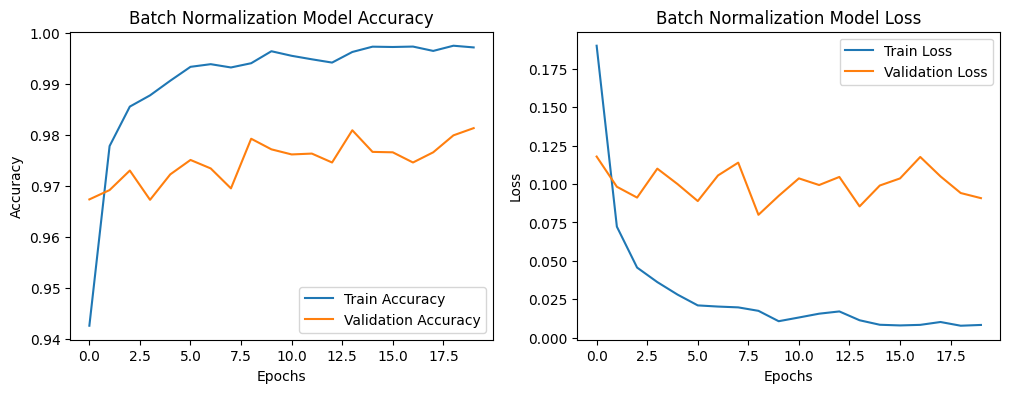

In [ ]:
# Model with Batch Normalization
bn_model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(512, activation='relu'),
    BatchNormalization(),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dense(10, activation='softmax')
])

bn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_bn = bn_model.fit(
    x_train, y_train,
    epochs=20,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

plot_history(history_bn, "Batch Normalization Model")
